# 01 — Evaluation rigor: measuring a high-variance agent honestly

Poker (like a trading backtest) is *high variance*: a few unlucky deals can swamp a real edge. This notebook reproduces — straight from the committed `results/*.json`, **no retraining** — how this project decides whether an edge is real:

1. **Paired seeds + bootstrap CIs + an exact binomial sign test** on the headline RL-vs-myopic match (the matches are binary bust outcomes, so the sign test is the right test; the paired t-test only corroborates).
2. **Variance reduction** (duplicate/mirror matching and an all-in-EV control variate, the DIVAT/AIVAT family — `REFERENCES.md` §2).
3. The honest verdict: *one edge resolves over the baseline under a pre-registered confirmatory run, the rest stay marginal* — and rigor, not a single headline number, is the deliverable.

In [1]:
import os, sys, json
# Walk up to the repo root (works whether the kernel cwd is notebooks/ or root).
ROOT = os.getcwd()
while not (os.path.isdir(os.path.join(ROOT, "results"))
          and os.path.isdir(os.path.join(ROOT, "src"))) \
        and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from IPython.display import Image, display

def load(name):
    with open(os.path.join(ROOT, "results", name)) as f:
        return json.load(f)

def fig(name):
    display(Image(filename=os.path.join(ROOT, "figures", name)))
print("repo root resolved:", os.path.basename(ROOT))

repo root resolved: poker-simulation


## 1. The headline edge — exploratory pilot, then pre-registered confirmatory

`results/headline_history.json` stores the per-seed chip differences of the **exploratory pilot** (single orientation, 200 seeds × 200 hands) that first surfaced the edge. `results/confirmatory.json` holds the **pre-registered confirmatory** run (`PREREGISTRATION.md` §4.3: 500 mirrored paired seeds × 100 hands via `evaluate_matchup`). We re-run the project's own `bootstrap_ci` and the **exact binomial sign test** (the right test — the matches are binary bust outcomes, so only the *sign* of each per-seed diff is informative) on both, and report the confirmatory as the primary number.

In [2]:
from src.stats import bootstrap_ci, paired_t_test, binomial_sign_test

# Exploratory pilot (single orientation, 200 seeds x 200 hands) -- first surfaced the edge.
h = load("headline_history.json")["final"]
pd = h["per_seed_diffs"]
pci = bootstrap_ci(pd); pb = binomial_sign_test(pd)
print(f"PILOT (exploratory, 200x200):  {pb['wins']}/{h['n_seeds']}  "
      f"mean {pci['mean']:+.0f}  95% CI [{pci['lo']:+.0f}, {pci['hi']:+.0f}]  "
      f"(committed [{h['ci95']['lo']:+.0f}, {h['ci95']['hi']:+.0f}])")

# Pre-registered confirmatory (PREREGISTRATION.md 4.3): 500 MIRRORED paired seeds.
c = load("confirmatory.json")["confirmatory_primary"]; cc = c["ci95"]
print(f"CONFIRMATORY (pre-registered, 500 mirrored):  {c['wins_rl']}-{c['wins_myopic']} W-L, "
      f"{c['ties']} seat-luck ties  mean {c['mean_diff']:+.0f}  "
      f"95% CI [{cc['lo']:+.0f}, {cc['hi']:+.0f}]  binomial p = {c['binom']['p_value']:.1e}")
print()
resolved = cc["lo"] > 0 or cc["hi"] < 0
verdict = ("EXCLUDES 0 -- a resolved edge over the baseline (the mirror cancels seat-luck,\n"
           "so the pilot's +500 tightens to a cleaner +256; the edge was already resolved\n"
           "in the pilot at 50 seeds -- 33/50, CI [+80, +1120] -- correct powering, not\n"
           "optional stopping)"
           if resolved else
           "straddles 0 -- a real but MARGINAL edge, not a decisive win")
print(f"Read it honestly: the confirmatory 95% CI {verdict}.")
print("Still modest: a 0-parameter Kelly bot beats this RL agent head-to-head.")

PILOT (exploratory, 200x200):  125/200  mean +500  95% CI [+240, +760]  (committed [+240, +760])
CONFIRMATORY (pre-registered, 500 mirrored):  132-68 W-L, 300 seat-luck ties  mean +256  95% CI [+144, +364]  binomial p = 7.1e-06

Read it honestly: the confirmatory 95% CI EXCLUDES 0 -- a resolved edge over the baseline (the mirror cancels seat-luck,
so the pilot's +500 tightens to a cleaner +256; the edge was already resolved
in the pilot at 50 seeds -- 33/50, CI [+80, +1120] -- correct powering, not
optional stopping).
Still modest: a 0-parameter Kelly bot beats this RL agent head-to-head.


## 2. Variance reduction — the same edge, measured four ways

`results/variance_reduction.json` measures one fixed edge (Myopic vs Aggro, 120 paired seeds) four ways. Duplicate/**mirror matching** (same deck, swapped seats) cancels seat/deck luck and narrows the CI; the all-in-EV control variate is ~neutral in this *bust-match* format (its big gains are for per-hand win-rate estimation).

In [3]:
vr = load("variance_reduction.json")
print(f"{'arm':14s} {'mean':>8s} {'CI width':>10s} {'% of raw':>9s}")
for a in vr["arms"]:
    print(f"{a['arm']:14s} {a['mean']:+8.1f} {a['ci_width']:10.0f} "
          f"{a['ci_width_vs_raw']:8.0%}")

arm                mean   CI width  % of raw
raw               +33.3        712     100%
mirror            +56.8        464      65%
luck_adjusted     +42.6        704      99%
mirror+luck       +63.1        458      64%


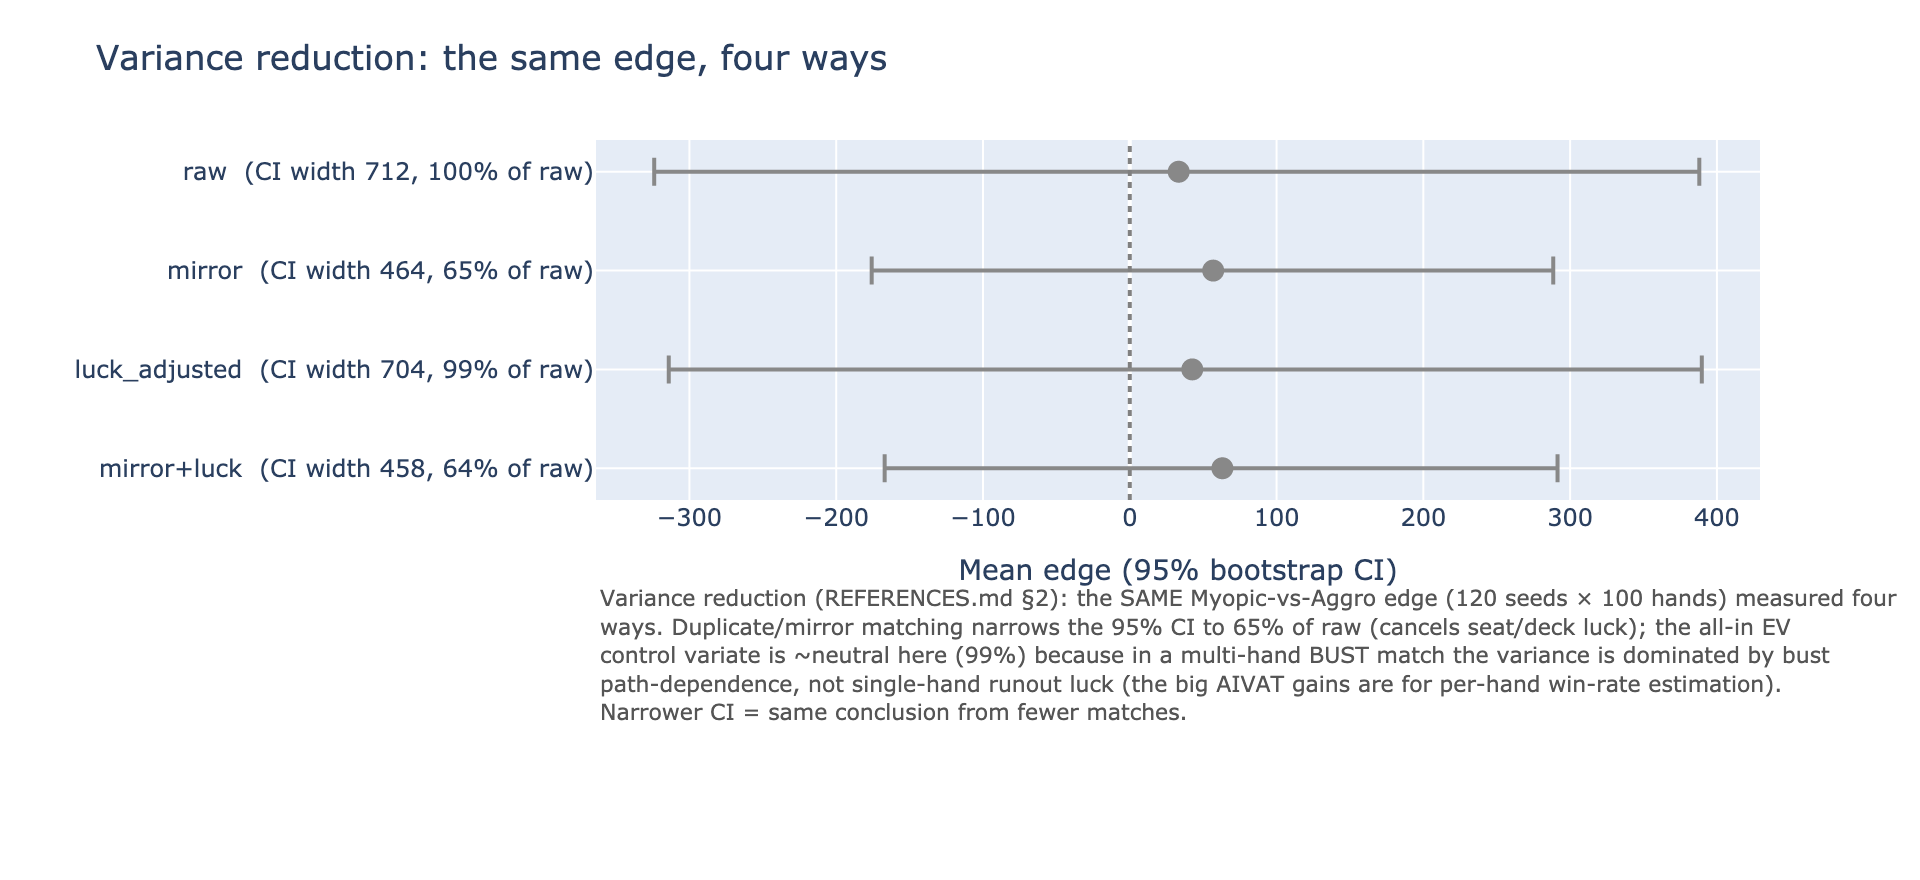

In [4]:
fig("variance_reduction.png")

## 3. Are *any* of the headline edges real?

The executive summary puts every claimed edge on one axis with its 95% bootstrap CI. Gray = the CI straddles 0 (within per-seed noise).

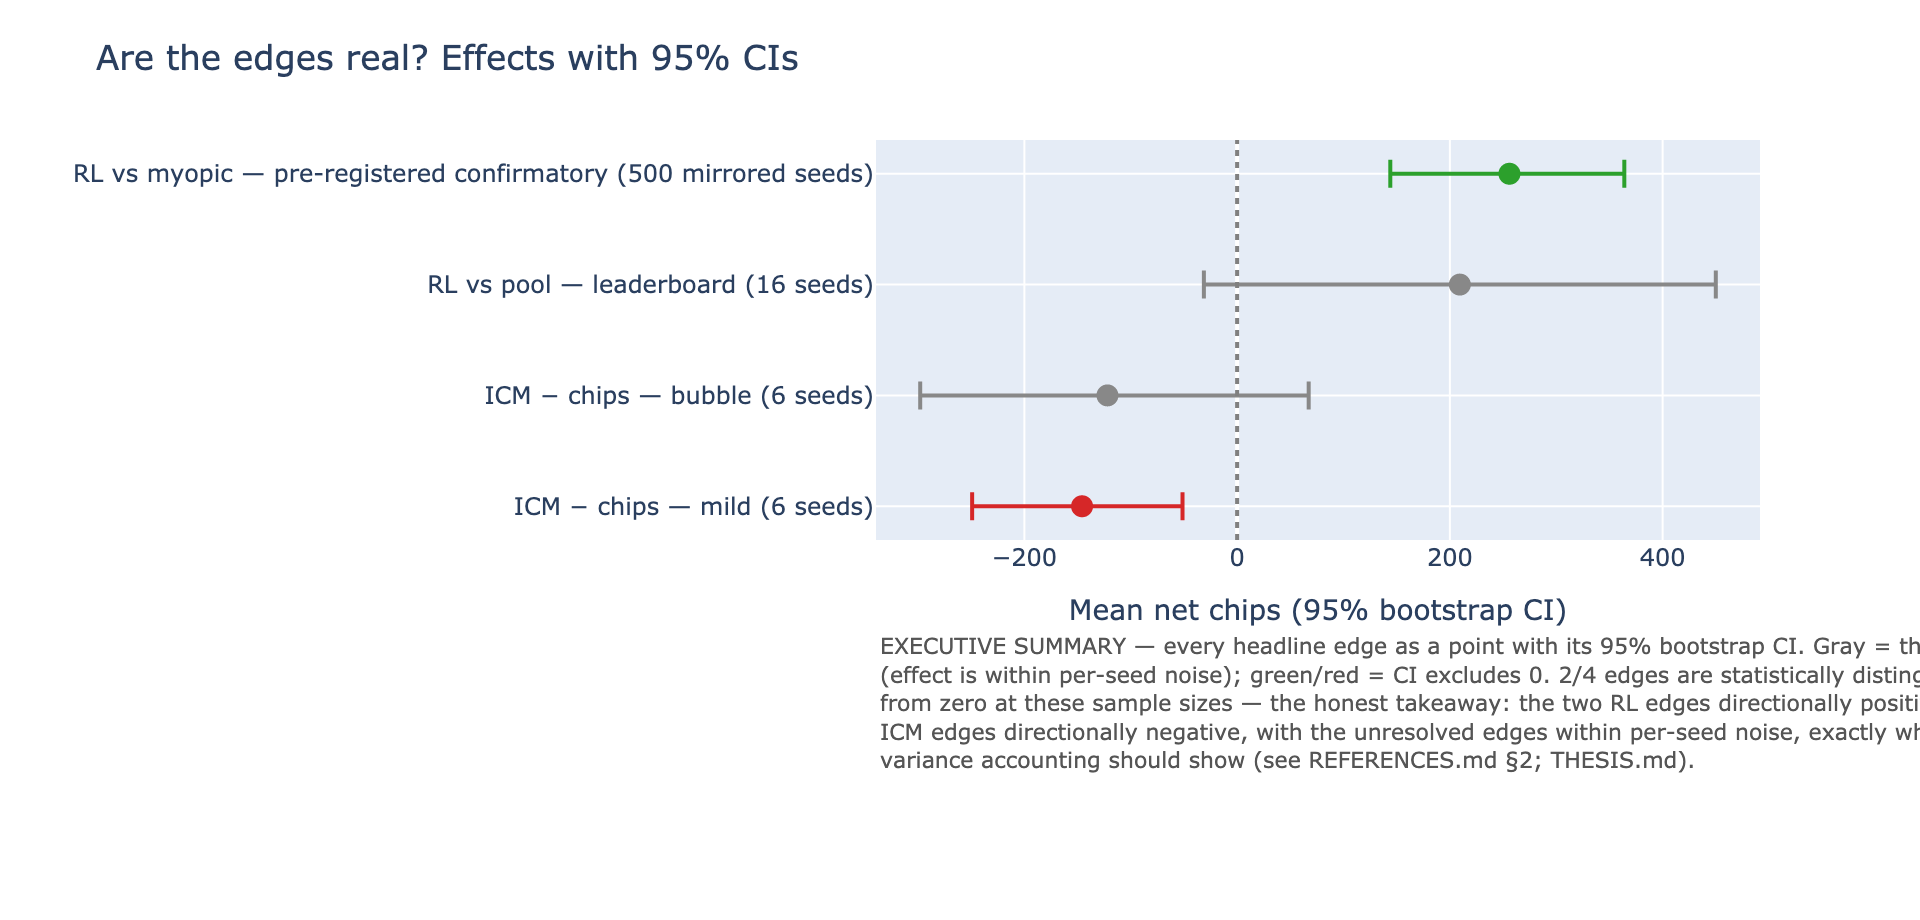

In [5]:
fig("exec_summary.png")

### Honest takeaway

The RL agent's edge over the myopic baseline **resolves** under the pre-registered confirmatory run (500 mirrored seeds: +256 chips, 95% CI [+144, +364], binomial p≈7×10⁻⁶; the exploratory pilot was +500 at 200 single-orientation seeds); the remaining edges (opponent pool, ICM/Kelly risk-aversion) stay marginal or directionally negative at these sample sizes — and a 0-parameter Kelly bot still beats the RL agent head-to-head (5-11). That mix — one resolved edge, honest nulls elsewhere — is the correct finding for a single-developer DQN in a high-variance game. The transferable artifact is the **measurement discipline** — paired design, bootstrap CIs, the *right* significance test, variance reduction — not a single headline number. See `THESIS.md` and `REFERENCES.md` §2.